# 06 — Black–Scholes: Theta por Diferencias Finitas

**Objetivo del notebook.** Estimar la $\Theta$ de una opción europea bajo Black–Scholes mediante diferencias finitas con CRN. El método pathwise no admite formulación directa (véase la Sección 3.4 de la memoria), por lo que el estudio se limita a FD.

## Convención y formulación

Adoptamos la convención clásica $\Theta = \partial V / \partial t$. Con $V(t, T) = V(0, T - t)$, derivar respecto a $t$ con $T$ fijo equivale a derivar respecto a $T$ con $t$ fijo cambiando de signo:

$$\Theta = -\frac{\partial V}{\partial T} \approx -\frac{V(0,\, T+h) - V(0,\, T-h)}{2h}.$$

El estimador FD perturba $T \to T \pm h$ usando la **misma** matriz $Z$ (CRN). Bajo NoOfSteps$=1$ (simulación exacta para BS), la única consecuencia operativa de cambiar $T$ es que el incremento browniano se reescala:

$$\Delta W^{up} = \sqrt{T+h}\,Z, \qquad \Delta W^{dn} = \sqrt{T-h}\,Z,$$

manteniendo la dependencia común en $Z$ que reduce la varianza.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bs_utils import (BS_theta,GeneratePathsGBM_givenZ,FD_Theta)

np.set_printoptions(suppress=True, precision=6)


## 1. Parámetros del experimento


In [2]:
CP        = 'call'
S0        = 100.0
K         = 100.0
sigma     = 0.20
r         = 0.05
T         = 1.0
t         = 0.0
NoOfSteps = 1            # simulación exacta en un único paso

SEED      = 3


## 2. Validación puntual


In [4]:
N = 100000
h = 0.005           # paso sobre T (~ 1 día y medio en años)

rng = np.random.default_rng(SEED)
Z = rng.normal(0.0, 1.0, (N, NoOfSteps))

theta_BS = BS_theta(CP, S0, K, sigma, t, T, r)
theta_FD = FD_Theta(CP, S0, K, sigma, T, r, h, Z)

print(f"Theta BS (analítica): {theta_BS:.6f}")
print(f"Theta FD (centrada):  {theta_FD:.6f}    error abs = {abs(theta_FD - theta_BS):.2e}")


Theta BS (analítica): -6.414028
Theta FD (centrada):  -6.415214    error abs = 1.19e-03


**Lectura.** $\Theta$ es negativa para una call europea: la opción pierde valor temporal al acercarse el vencimiento. El estimador FD reproduce el valor analítico con error muestral del orden de $10^{-3}$ con $N = 10^5$.

> **Nota técnica.** El signo negativo del estimador en `FD_Theta` (`bs_utils.py`) refleja la convención $\partial V/\partial t = -\partial V/\partial T$. La perturbación numérica se efectúa sobre $T$ (cantidad accesible directamente en la simulación), pero el resultado se interpreta como sensibilidad al paso del tiempo.


## 3. Convergencia frente a $N$


In [5]:
N_list = [1000, 5000, 10000, 50000, 100000]
results = []

rng = np.random.default_rng(SEED)
for N in N_list:
    Z = rng.normal(0.0, 1.0, (N, NoOfSteps))
    theta_FD = FD_Theta(CP, S0, K, sigma, T, r, h, Z)
    
    results.append([
        N,
        theta_FD, abs(theta_FD - theta_BS),
        1.0/np.sqrt(N)
    ])

df_N = pd.DataFrame(results, columns=["N", "Theta_FD", "Error_FD", "MC_rate"])
df_N


,N,Theta_FD,Error_FD,MC_rate
0,1000,-6.377294,0.036734,0.031623
1,5000,-6.433177,0.019149,0.014142
2,10000,-6.444778,0.030751,0.010000
3,50000,-6.407728,0.006299,0.004472
4,100000,-6.414011,0.000016,0.003162


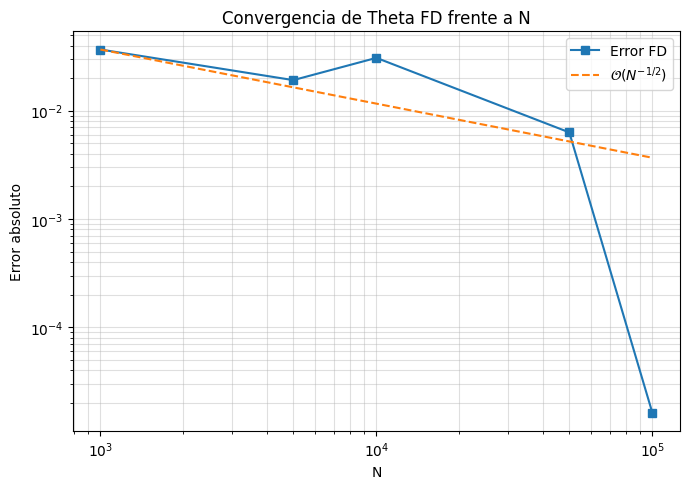

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(df_N["N"], df_N["Error_FD"], "s-", label="Error FD")
scale = df_N["Error_FD"].iloc[0] * np.sqrt(df_N["N"].iloc[0])
ax.loglog(df_N["N"], scale/np.sqrt(df_N["N"]), "--",
          label=r"$\mathcal{O}(N^{-1/2})$")
ax.set_xlabel("N")
ax.set_ylabel("Error absoluto")
ax.set_title("Convergencia de Theta FD frente a N")
ax.grid(True, which="both", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()


**Lectura.** Convergencia $\mathcal{O}(N^{-1/2})$ confirmada. La constante es comparable a la de Delta y Vega, ya que el operador es de primera diferencia (a diferencia de Gamma).


## 4. Estabilidad estadística: varianza del estimador


In [7]:
def estimador_theta(CP, S0, K, r, T, sigma, NoOfPaths, NoOfSteps, h, rng):
    """    Devuelve theta_FD con CRN: misma Z para las perturbaciones T +/- h."""
    Z = rng.normal(0.0, 1.0, (NoOfPaths, NoOfSteps))
    return FD_Theta(CP, S0, K, sigma, T, r, h, Z)


In [8]:
N_list = [1000, 5000, 10000, 50000]
M = 100

rng = np.random.default_rng(SEED)
results_var = []

for N in N_list:
    fd_vals = np.empty(M)
    for j in range(M):
        fd_vals[j] = estimador_theta(CP, S0, K, r, T, sigma, N, NoOfSteps, h, rng)
    
    results_var.append([
        N,
        np.mean(fd_vals), np.var(fd_vals, ddof=1), np.std(fd_vals, ddof=1),
    ])

df_var = pd.DataFrame(results_var, columns=["N", "Mean_FD", "Var_FD", "Std_FD"])
df_var


,N,Mean_FD,Var_FD,Std_FD
0,1000,-6.415324,0.001044,0.032316
1,5000,-6.414489,0.000187,0.013683
2,10000,-6.413711,0.000108,0.010389
3,50000,-6.414093,0.000017,0.004137


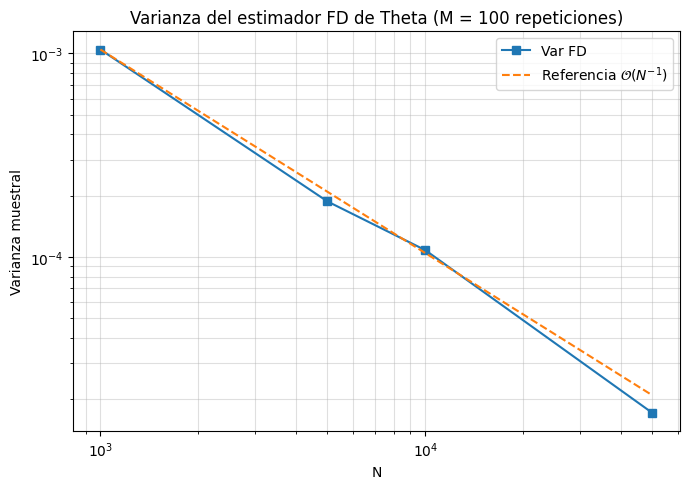

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(df_var["N"], df_var["Var_FD"], "s-", label="Var FD")
ax.set_xlabel("N")
ax.set_ylabel("Varianza muestral")

scale = df_var["Var_FD"].iloc[0] * df_var["N"].iloc[0]
ax.loglog(df_var["N"], scale / df_var["N"], "--",
          label=r"Referencia $\mathcal{O}(N^{-1})$")


ax.set_title(f"Varianza del estimador FD de Theta (M = {M} repeticiones)")
ax.grid(True, which="both", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()


**Lectura.** Varianza decreciente a tasa $1/N$ tras CRN. Sin reutilización de $Z$ entre las perturbaciones $T \pm h$, la varianza explotaría como $1/h^2$ a $h$ pequeño; con CRN se mantiene aproximadamente constante en el rango operativo de $h$.


## 5. Sensibilidad respecto al paso $h$

Para $\Theta$, el compromiso sesgo–varianza es análogo al de las Griegas de primer orden (Delta, Vega): sesgo $\mathcal{O}(h^2)$ por diferencia centrada, frente a una varianza que, gracias al CRN, permanece aproximadamente plana en $h$. Esto contrasta con Gamma, donde la varianza crece incluso con CRN.

La razón es estructural: $\Theta$ se estima mediante una diferencia centrada de primer orden en $T$, de modo que el numerador $V(T+h) - V(T-h)$ es $\mathcal{O}(h)$ con varianza $\mathcal{O}(h^2)$ bajo CRN, que cancela exactamente el $1/(2h)$ del denominador. El estimador hereda así la misma estabilidad que Delta o Vega.


In [17]:
# Lo que necesitas para ver la U:
h_list = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
N_h = 10000
M_h = 200

rng = np.random.default_rng(SEED)
fd_all = {h_val: np.empty(M_h) for h_val in h_list}

for j in range(M_h):
    Z = rng.normal(0.0, 1.0, (N_h, NoOfSteps))
    for h_val in h_list:
        fd_all[h_val][j] = FD_Theta(CP, S0, K, sigma, T, r, h_val, Z)

rows = []
for h_val in h_list:
    fd_v = fd_all[h_val]
    mean_fd = np.mean(fd_v); var_fd = np.var(fd_v, ddof=1)
    bias_fd = mean_fd - theta_BS; mse_fd = var_fd + bias_fd**2
    rows.append([h_val, mean_fd, bias_fd, abs(bias_fd), var_fd, mse_fd])

df_h = pd.DataFrame(rows, columns=[
    "h", "Mean_FD", "Bias_FD", "AbsBias_FD", "Var_FD", "MSE_FD"
])
df_h


,h,Mean_FD,Bias_FD,AbsBias_FD,Var_FD,MSE_FD
0,0.001,-6.414187,-0.000160,0.000160,0.000098,0.000098
1,0.005,-6.414197,-0.000169,0.000169,0.000098,0.000098
2,0.010,-6.414232,-0.000205,0.000205,0.000099,0.000099
3,0.050,-6.415433,-0.001405,0.001405,0.000099,0.000101
4,0.100,-6.419189,-0.005162,0.005162,0.000099,0.000126
5,0.200,-6.434416,-0.020388,0.020388,0.000099,0.000515
6,0.300,-6.460743,-0.046716,0.046716,0.000100,0.002282
7,0.500,-6.554330,-0.140302,0.140302,0.000103,0.019788


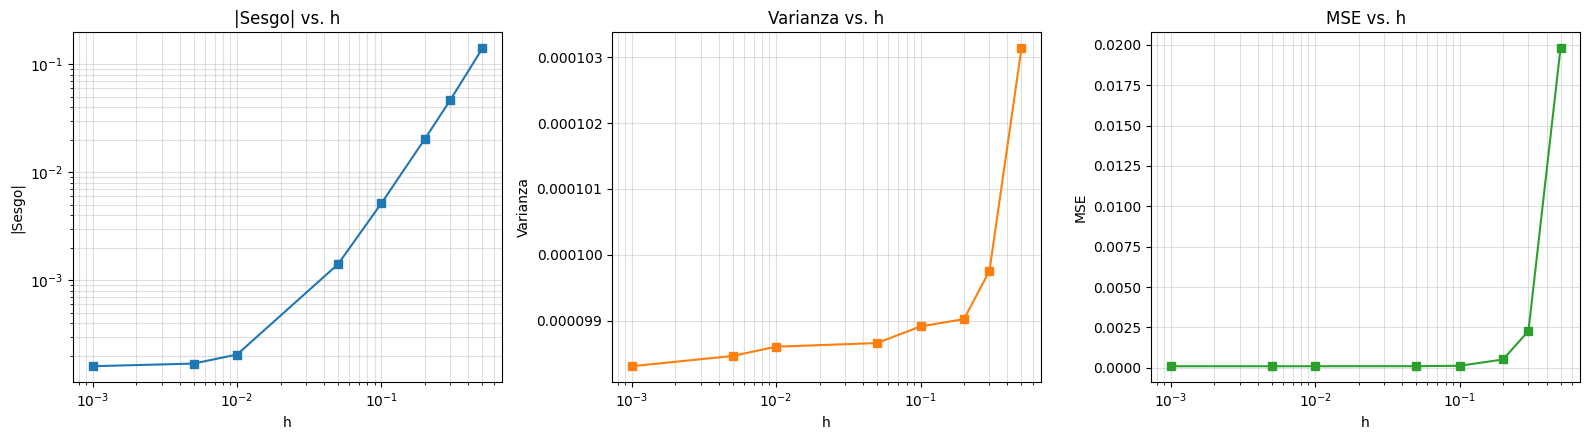

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].loglog(df_h["h"], df_h["AbsBias_FD"], "s-")
axes[0].set_xlabel("h"); axes[0].set_ylabel("|Sesgo|")
axes[0].set_title("|Sesgo| vs. h")
axes[0].grid(True, which="both", alpha=0.4)

axes[1].semilogx(df_h["h"], df_h["Var_FD"], "s-", color="tab:orange")
axes[1].set_xlabel("h"); axes[1].set_ylabel("Varianza")
axes[1].set_title("Varianza vs. h")
axes[1].grid(True, which="both", alpha=0.4)

axes[2].semilogx(df_h["h"], df_h["MSE_FD"], "s-", color="tab:green")
axes[2].set_xlabel("h"); axes[2].set_ylabel("MSE")
axes[2].set_title("MSE vs. h")
axes[2].grid(True, which="both", alpha=0.4)

plt.tight_layout()
plt.show()


**Lectura.**

- **Sesgo.** Crece como $h^2$ en el rango $h \in [0{,}05,\, 0{,}5]$, conforme a la fórmula de truncamiento del FD centrado de segundo orden. Para $h \leq 0{,}01$ el sesgo satura al nivel del ruido Monte Carlo ($M = 200$ réplicas) y deja de ser estimable con precisión.

- **Varianza.** Aproximadamente plana en todo el rango explorado ($\approx 9{,}8 \times 10^{-5}$), con una subida marginal solo para 
  $h \geq 0{,}3$. Esto es una consecuencia directa del CRN: al usar la misma 
  $Z$ en las simulaciones $T+h$ y $T-h$, la diferencia $V(T+h) - V(T-h)$ es 
  $\mathcal{O}(h)$ con varianza $\mathcal{O}(h^2)$, que cancela exactamente 
  el $1/(2h)$ del denominador. La varianza del estimador es así 
  $\mathcal{O}(1/N)$, independiente de $h$, igual que en Delta o Vega.

- **MSE.** No existe curva en U. Dado que la varianza es plana, el MSE 
  $= \text{Var} + \text{sesgo}^2$ es monótonamente creciente en $h$. El mínimo se alcanza en $h \to 0$, acotado por el suelo de varianza Monte Carlo. En la práctica, cualquier $h \in [10^{-3},\, 5 \times 10^{-2}]$ es igualmente válido.


## 6. Conclusiones del notebook

1. FD con CRN reproduce la $\Theta$ analítica con tasa $\mathcal{O}(N^{-1/2})$ y precisión comparable a Delta y Vega.
2. **Pathwise no admite formulación directa para $\Theta$**: la perturbación de $T$ altera la simulación del proceso completo, y la condición de intercambio $\partial - \mathbb{E}$ no se aplica como en Delta, Vega o Rho.
3. El compromiso sesgo–varianza es estándar (igual orden que primera diferencia), y el CRN es nuevamente esencial para acotar la varianza al perturbar $T \pm h$ con la misma matriz $Z$.
